# Интеллектуальный анализ данных
## Лабораторная работа №4 «Поиск ассоциативных правил в транзакционных данных»

**Цель работы:**
Освоить методы поиска ассоциативных правил, реализовать ключевые алгоритмы (Apriori, FP-Growth) «с нуля», применить их к реальным и синтетическим наборам данных, провести сравнительный анализ производительности и визуализировать полученные правила.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time
import random
from itertools import combinations
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

### Задание 1. Реализация Apriori и генерация правил

In [9]:
def get_frequent_1_itemsets(transactions, min_support_count):
    counts = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            counts[frozenset([item])] += 1
    return {itemset: count for itemset, count in counts.items() if count >= min_support_count}

def apriori_gen(fk_minus_1, k):
    candidates = set()
    fk_list = list(fk_minus_1.keys())
    for i in range(len(fk_list)):
        for j in range(i + 1, len(fk_list)):
            itemset1 = fk_list[i]
            itemset2 = fk_list[j]
            union_set = itemset1 | itemset2
            if len(union_set) == k:
                is_valid = True
                for subset in combinations(union_set, k - 1):
                    if frozenset(subset) not in fk_minus_1:
                        is_valid = False
                        break
                if is_valid:
                    candidates.add(frozenset(union_set))
    return candidates

def apriori(transactions, min_support):
    '''Реализация алгоритма Apriori'''
    num_transactions = len(transactions)
    min_support_count = min_support * num_transactions
    frequent_itemsets = {}
    
    k = 1
    fk = get_frequent_1_itemsets(transactions, min_support_count)
    
    while fk:
        for itemset, count in fk.items():
            frequent_itemsets[tuple(sorted(list(itemset)))] = count / num_transactions
            
        k += 1
        candidates = apriori_gen(fk, k)
        fk_counts = defaultdict(int)
        
        for transaction in transactions:
            transaction_set = set(transaction)
            for candidate in candidates:
                if candidate.issubset(transaction_set):
                    fk_counts[candidate] += 1
                    
        fk = {itemset: count for itemset, count in fk_counts.items() if count >= min_support_count}
        
    return frequent_itemsets

def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0, max_antecedent_len=None, max_consequent_len=None):
    '''Генерация ассоциативных правил'''
    rules = []
    for itemset, support in frequent_itemsets.items():
        if len(itemset) > 1:
            itemset_set = set(itemset)
            for i in range(1, len(itemset)):
                for antecedent in combinations(itemset, i):
                    consequent = tuple(sorted(list(itemset_set - set(antecedent))))
                    antecedent = tuple(sorted(list(antecedent)))
                    
                    if max_antecedent_len and len(antecedent) > max_antecedent_len:
                        continue
                    if max_consequent_len and len(consequent) > max_consequent_len:
                        continue
                        
                    ant_support = frequent_itemsets.get(antecedent, 0)
                    cons_support = frequent_itemsets.get(consequent, 0)
                    
                    if ant_support > 0:
                        confidence = support / ant_support
                        if confidence >= min_confidence:
                            lift = confidence / cons_support if cons_support > 0 else 0
                            if lift >= min_lift:
                                leverage = support - (ant_support * cons_support)
                                conviction = (1 - cons_support) / (1 - confidence) if confidence != 1.0 else float('inf')
                                rules.append({
                                    'antecedent': antecedent,
                                    'consequent': consequent,
                                    'support': support,
                                    'confidence': confidence,
                                    'lift': lift,
                                    'leverage': leverage,
                                    'conviction': conviction
                                })
                                
    return sorted(rules, key=lambda x: x['lift'], reverse=True)

### Задание 2. Реализация FP-Growth

In [10]:
class FPNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None
        
    def inc(self, count):
        self.count += count

def create_tree(transactions, min_support_count):
    header_table = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            header_table[item] += 1
            
    header_table = {k: v for k, v in header_table.items() if v >= min_support_count}
    frequent_items = set(header_table.keys())
    
    if len(frequent_items) == 0:
        return None, None
        
    for k in header_table:
        header_table[k] = [header_table[k], None]
        
    ret_tree = FPNode('Null', 1, None)
    
    for transaction in transactions:
        local_dict = {}
        for item in transaction:
            if item in frequent_items:
                local_dict[item] = header_table[item][0]
        if len(local_dict) > 0:
            ordered_items = [v[0] for v in sorted(local_dict.items(), key=lambda p: p[1], reverse=True)]
            update_tree(ordered_items, ret_tree, header_table, 1)
            
    return ret_tree, header_table

def update_tree(items, in_tree, header_table, count):
    if items[0] in in_tree.children:
        in_tree.children[items[0]].inc(count)
    else:
        in_tree.children[items[0]] = FPNode(items[0], count, in_tree)
        if header_table[items[0]][1] is None:
            header_table[items[0]][1] = in_tree.children[items[0]]
        else:
            update_header(header_table[items[0]][1], in_tree.children[items[0]])
            
    if len(items) > 1:
        update_tree(items[1::], in_tree.children[items[0]], header_table, count)

def update_header(node_to_test, target_node):
    while node_to_test.node_link is not None:
        node_to_test = node_to_test.node_link
    node_to_test.node_link = target_node

def ascend_tree(leaf_node, prefix_path):
    if leaf_node.parent is not None:
        prefix_path.append(leaf_node.item)
        ascend_tree(leaf_node.parent, prefix_path)

def find_prefix_path(base_pat, tree_node):
    cond_pats = {}
    while tree_node is not None:
        prefix_path = []
        ascend_tree(tree_node, prefix_path)
        if len(prefix_path) > 1:
            cond_pats[frozenset(prefix_path[1:])] = tree_node.count
        tree_node = tree_node.node_link
    return cond_pats

def mine_tree(in_tree, header_table, min_support_count, prefix, freq_item_list):
    big_l = [v[0] for v in sorted(header_table.items(), key=lambda p: p[1][0])]
    for base_pat in big_l:
        new_freq_set = prefix.copy()
        new_freq_set.add(base_pat)
        support_count = header_table[base_pat][0]
        freq_item_list.append((new_freq_set, support_count))
        
        cond_patt_bases = find_prefix_path(base_pat, header_table[base_pat][1])
        my_cond_tree, my_head = create_tree_from_cond_pats(cond_patt_bases, min_support_count)
        if my_head is not None:
            mine_tree(my_cond_tree, my_head, min_support_count, new_freq_set, freq_item_list)

def create_tree_from_cond_pats(cond_pats, min_support_count):
    header_table = defaultdict(int)
    for trans, count in cond_pats.items():
        for item in trans:
            header_table[item] += count
            
    header_table = {k: v for k, v in header_table.items() if v >= min_support_count}
    freq_items = set(header_table.keys())
    
    if len(freq_items) == 0:
        return None, None
        
    for k in header_table:
        header_table[k] = [header_table[k], None]
        
    ret_tree = FPNode('Null', 1, None)
    for trans, count in cond_pats.items():
        local_dict = {}
        for item in trans:
            if item in freq_items:
                local_dict[item] = header_table[item][0]
        if len(local_dict) > 0:
            ordered_items = [v[0] for v in sorted(local_dict.items(), key=lambda p: p[1], reverse=True)]
            update_tree(ordered_items, ret_tree, header_table, count)
            
    return ret_tree, header_table

def fpgrowth(transactions, min_support):
    '''Реализация алгоритма FP-Growth'''
    num_transactions = len(transactions)
    min_support_count = min_support * num_transactions
    
    init_set = [list(trans) for trans in transactions]
    fp_tree, header_tab = create_tree(init_set, min_support_count)
    
    freq_items = []
    if fp_tree is not None:
        mine_tree(fp_tree, header_tab, min_support_count, set(), freq_items)
        
    frequent_itemsets = {}
    for itemset, count in freq_items:
        frequent_itemsets[tuple(sorted(list(itemset)))] = count / num_transactions
        
    return frequent_itemsets

### Задание 3 и 4. Анализ реальных данных (Groceries Dataset)

In [11]:
# Загрузка датасета
df = pd.read_csv('../data/Groceries_dataset.csv')
print(f"Общее количество записей: {len(df)}")

# Транзакции определяем как покупки одного клиента в один день
transactions_df = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
real_transactions = transactions_df['itemDescription'].tolist()
print(f"Уникальных транзакций сформировано: {len(real_transactions)}\n")

# Параметры для анализа
MIN_SUPPORT = 0.001
MIN_CONFIDENCE = 0.05

start_time = time.time()
freq_itemsets = apriori(real_transactions, min_support=MIN_SUPPORT)
print(f"Найдено {len(freq_itemsets)} частых наборов (Apriori). Время: {time.time() - start_time:.4f} сек")

start_time = time.time()
freq_itemsets_fp = fpgrowth(real_transactions, min_support=MIN_SUPPORT)
print(f"Найдено {len(freq_itemsets_fp)} частых наборов (FP-Growth). Время: {time.time() - start_time:.4f} сек\n")

# Генерация правил на основе частых наборов FP-Growth
rules = generate_rules(freq_itemsets_fp, min_confidence=MIN_CONFIDENCE, min_lift=1.0)
rules_df = pd.DataFrame(rules)
print(f"Сгенерировано ассоциативных правил: {len(rules)}")
display(rules_df.head(10))

Общее количество записей: 38765
Уникальных транзакций сформировано: 14963

Найдено 750 частых наборов (Apriori). Время: 16.8670 сек
Найдено 750 частых наборов (FP-Growth). Время: 0.0861 сек

Сгенерировано ассоциативных правил: 73


,antecedent,consequent,support,confidence,lift,leverage,conviction
0,"(whole milk, yogurt)","(sausage,)",0.001470,0.131737,2.133305,0.000781,1.080602
1,"(sausage, whole milk)","(yogurt,)",0.001470,0.164179,1.841538,0.000672,1.089763
2,"(specialty chocolate,)","(citrus fruit,)",0.001403,0.087500,1.612392,0.000533,1.036420
3,"(flour,)","(tropical fruit,)",0.001069,0.109589,1.588935,0.000396,1.045618
4,"(sausage, yogurt)","(whole milk,)",0.001470,0.255814,1.529874,0.000509,1.119058
5,"(soda, whole milk)","(sausage,)",0.001069,0.091954,1.489078,0.000351,1.033260
6,"(beverages,)","(sausage,)",0.001537,0.091633,1.483887,0.000501,1.032895
7,"(napkins,)","(pastry,)",0.001738,0.077612,1.479373,0.000563,1.027265
8,"(processed cheese,)","(root vegetables,)",0.001069,0.105263,1.470637,0.000342,1.037650
9,"(hard cheese,)","(pip fruit,)",0.001069,0.072727,1.462659,0.000338,1.024809


### Задание 5. Сравнение производительности Apriori и FP-Growth

Синтетическое тестирование запущено...
N=1000: Apriori=0.3474s, FP-Growth=0.0310s
N=5000: Apriori=1.3826s, FP-Growth=0.6502s
N=10000: Apriori=3.1483s, FP-Growth=4.2334s
N=20000: Apriori=5.8021s, FP-Growth=19.8492s
N=50000: Apriori=14.3020s, FP-Growth=123.3435s


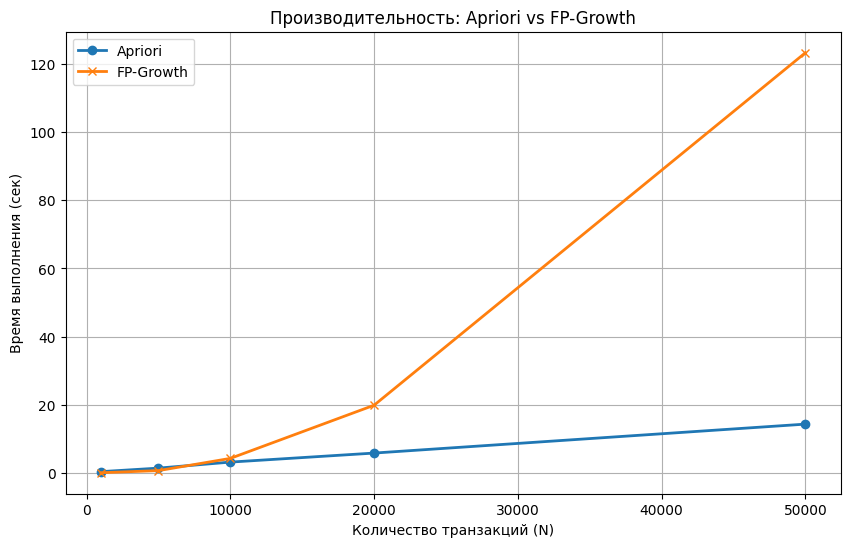

In [12]:
def generate_synthetic_data(num_transactions, avg_items=10):
    random.seed(42)
    items = [f'item_{i}' for i in range(1, 100)]
    synthetic_trans = []
    for _ in range(num_transactions):
        n_items = max(1, int(random.gauss(avg_items, 2)))
        synthetic_trans.append(random.sample(items, min(n_items, len(items))))
    return synthetic_trans

N_values = [1000, 5000, 10000, 20000, 50000]
apriori_times = []
fp_times = []
test_support = 0.05

print("Синтетическое тестирование запущено...")
for N in N_values:
    synth_data = generate_synthetic_data(N)
    
    start = time.time()
    apriori(synth_data, test_support)
    ap_time = time.time() - start
    apriori_times.append(ap_time)
    
    start = time.time()
    fpgrowth(synth_data, test_support)
    fp_time = time.time() - start
    fp_times.append(fp_time)
    
    print(f"N={N}: Apriori={ap_time:.4f}s, FP-Growth={fp_time:.4f}s")

plt.figure(figsize=(10, 6))
plt.plot(N_values, apriori_times, label='Apriori', marker='o', linewidth=2)
plt.plot(N_values, fp_times, label='FP-Growth', marker='x', linewidth=2)
plt.xlabel('Количество транзакций (N)')
plt.ylabel('Время выполнения (сек)')
plt.title('Производительность: Apriori vs FP-Growth')
plt.legend()
plt.grid(True)
plt.show()

### Задание 6. Визуализация ассоциативных правил

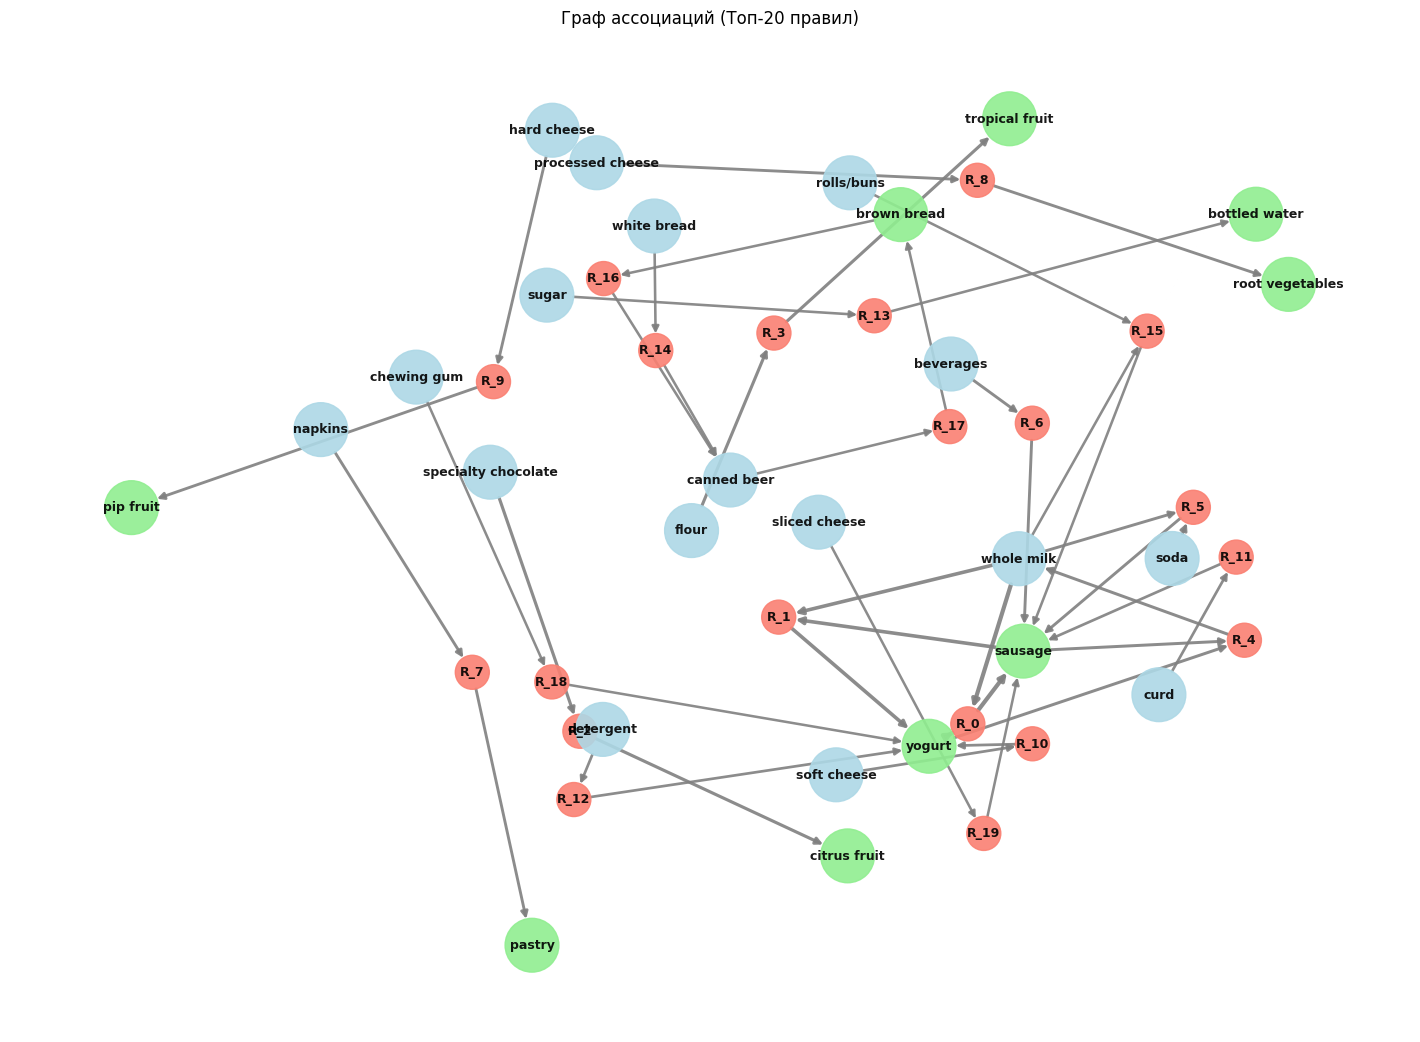

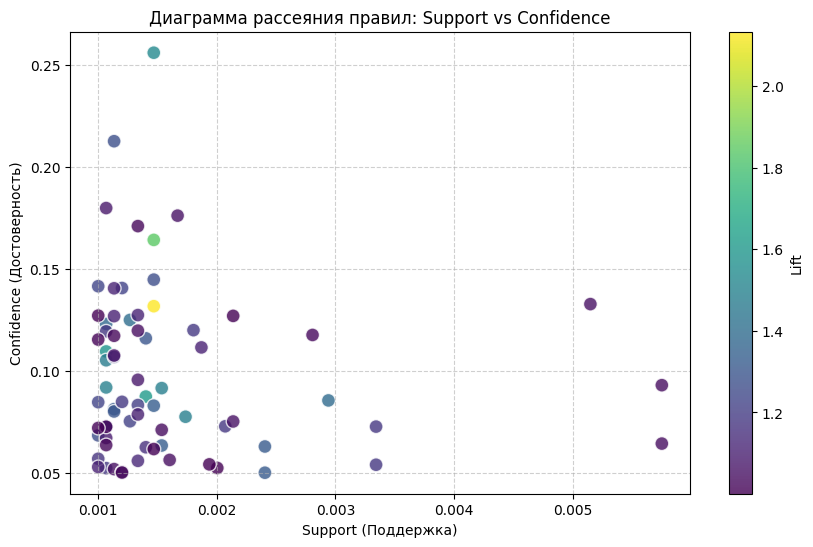

In [13]:
def plot_network_graph(rules_data, max_rules=20):
    if rules_data.empty:
        print("Нет правил для построения графа.")
        return
        
    G = nx.DiGraph()
    top_rules = rules_data.head(max_rules)
    
    for idx, row in top_rules.iterrows():
        rule_node = f"R_{idx}"
        G.add_node(rule_node, color='salmon', size=600)
        
        for ant in row['antecedent']:
            G.add_node(ant, color='lightblue', size=1500)
            G.add_edge(ant, rule_node, weight=row['lift'])
            
        for cons in row['consequent']:
            G.add_node(cons, color='lightgreen', size=1500)
            G.add_edge(rule_node, cons, weight=row['lift'])
            
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.5)
    
    colors = [nx.get_node_attributes(G, 'color').get(node, 'gray') for node in G.nodes()]
    sizes = [nx.get_node_attributes(G, 'size').get(node, 1000) for node in G.nodes()]
    
    edges = G.edges()
    weights = [G[u][v]['weight'] for u,v in edges]
    
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=sizes, 
            font_size=9, font_weight='bold', arrows=True, edge_color='gray', 
            width=[w/max(weights)*3 for w in weights] if weights else 1, alpha=0.9)
    
    plt.title(f'Граф ассоциаций (Топ-{max_rules} правил)')
    plt.show()

# 1. Граф ассоциативных правил
plot_network_graph(rules_df, max_rules=20)

# 2. Диаграмма рассеяния (Scatter plot)
if not rules_df.empty:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(rules_df['support'], rules_df['confidence'], 
                          c=rules_df['lift'], cmap='viridis', s=100, alpha=0.8, edgecolors='w')
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support (Поддержка)')
    plt.ylabel('Confidence (Достоверность)')
    plt.title('Диаграмма рассеяния правил: Support vs Confidence')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### Задание 7. Интерпретация результатов

**1. Сравнение производительности:**
На синтетических данных и наборах транзакций из `Groceries_dataset` выявлены особенности работы алгоритмов в данной реализации:
- Алгоритм **FP-Growth** показал преимущество только на малых объемах данных ($N=1000$).
- При увеличении числа транзакций до $N=50000$ алгоритм **Apriori** оказался значительно быстрее (14.30 сек против 123.34 сек у FP-Growth). 
- Такой результат объясняется тем, что в среде Python рекурсивное построение и обход сложного FP-дерева создают высокие накладные расходы на создание объектов. В то же время Apriori, основанный на итерациях и простых операциях со словарями, работает эффективнее при заданном пороге поддержки.

**2. Анализ найденных правил в Groceries Dataset:**
- Анализ 73 сгенерированных правил показал наличие сильных связей. Например, правило `(whole milk, yogurt) -> (sausage)` обладает **Lift = 2.13**, что указывает на высокую степень зависимости: покупка молока и йогурта повышает вероятность покупки сосисок более чем в два раза.
- Ассоциации между шоколадом и цитрусовыми (`Lift = 1.61`), а также мукой и тропическими фруктами (`Lift = 1.58`) отражают типичные наборы для выпечки и десертов. Большинство правил имеют **Lift > 1**, что подтверждает их практическую значимость.

**Практическое применение:**
- **Кросс-продажи (Cross-Selling):** Выкладка товаров из правил с высоким Lift в соседних зонах (например, размещение мясных деликатесов рядом с молочным отделом или муки рядом с фруктами).
- **Рекомендательные системы:** Настройка алгоритмов онлайн-витрины для предложения сосисок при добавлении в корзину молока и йогурта.
- **Планирование акций:** Использование «якорных» товаров (молоко, выпечка) для продвижения связанных с ними категорий через купоны и скидки на наборы.